# Importing

## Libraries and dependencies

In [108]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve, average_precision_score
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sb
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

## Functions

In [103]:
def model(classificator, X_train, y_train, X_test, y_test, title='Model'):
    
    classificator.fit(X_train, y_train)
    y_pred = classificator.predict(X_test)
    y_proba = classificator.predict_proba(X_test)[:, 1]

    print(f"Average Precision: {average_precision_score(y_test, y_proba):.2%}")
    print(f"Precision Score: {precision_score(y_test, y_pred):.2%}")
    print(f"Recall Score: {recall_score(y_test, y_pred):.2%}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.2%}")
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC Score (test): {roc_auc:.2%}")
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], '--')
    plt.title(f"ROC Curve - {title}")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()


In [3]:
def confusion(classificator, X_test, y_test):
    
    cm = confusion_matrix(y_test, classificator.predict(X_test))
    nomes = ['True Negative','False Positive','False Negative','True Positive']
    counts = [value for value in cm.flatten()]
    porcentagens = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(nomes, counts, porcentagens)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (16, 9))
    sns.heatmap(cm, annot = labels, cmap = 'Blues', fmt ='')
    plt.show();

## Dataset

In [12]:
df = pd.read_csv('dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# Data Cleaning & Exploratory Analysis

In [13]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 6362620
Number of columns: 11


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [21]:
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


In [23]:
missing = df.isna().sum()
print(f"Number of missing values:")
print(missing)

Number of missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [24]:
df["step_hour"] = df["step"] % 24

In [25]:
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1)

Transactions count:
0    6354407
1       8213
Name: isFraud, dtype: int64


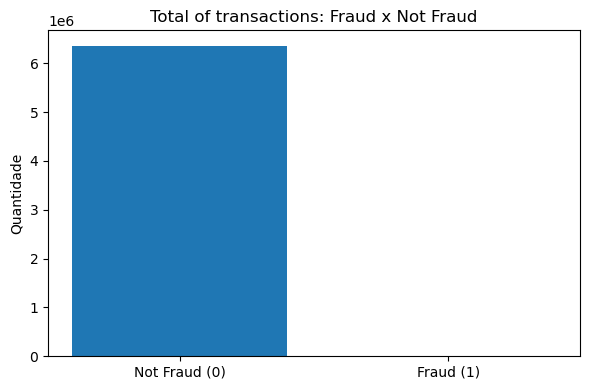

In [27]:
counts = df['isFraud'].value_counts().sort_index()

print("Transactions count:")
print(counts)

labels = ['Not Fraud (0)', 'Fraud (1)']

plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values)
plt.ylabel('Quantidade')
plt.title('Total of transactions: Fraud x Not Fraud')
plt.tight_layout()
plt.show()

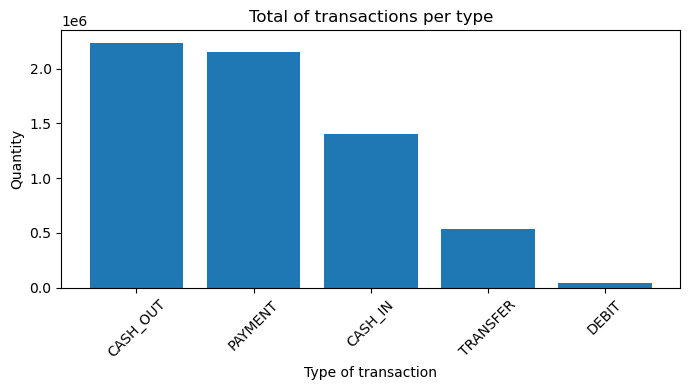

In [30]:
trans_per_type = df['type'].value_counts()

plt.figure(figsize=(7,4))
plt.bar(trans_per_type.index, trans_per_type.values)
plt.title("Total of transactions per type")
plt.xlabel("Type of transaction")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

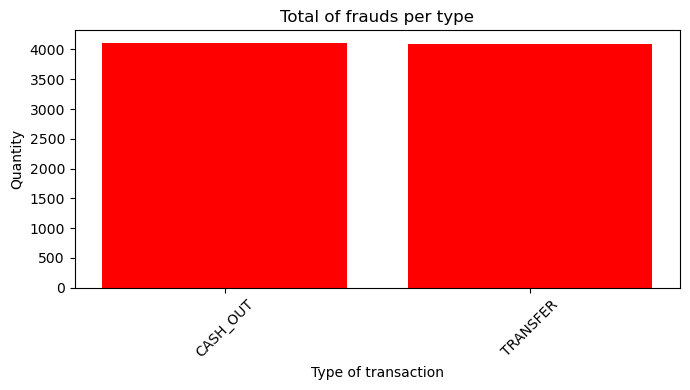

Transactions count:
CASH_OUT    4116
TRANSFER    4097
Name: type, dtype: int64


In [32]:
fraudes_per_type = df[df['isFraud'] == 1]['type'].value_counts()

plt.figure(figsize=(7,4))
plt.bar(fraudes_per_type.index, fraudes_per_type.values, color='red')
plt.title("Total of frauds per type")
plt.xlabel("Type of transaction")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Transactions count:")
print(fraudes_per_type)

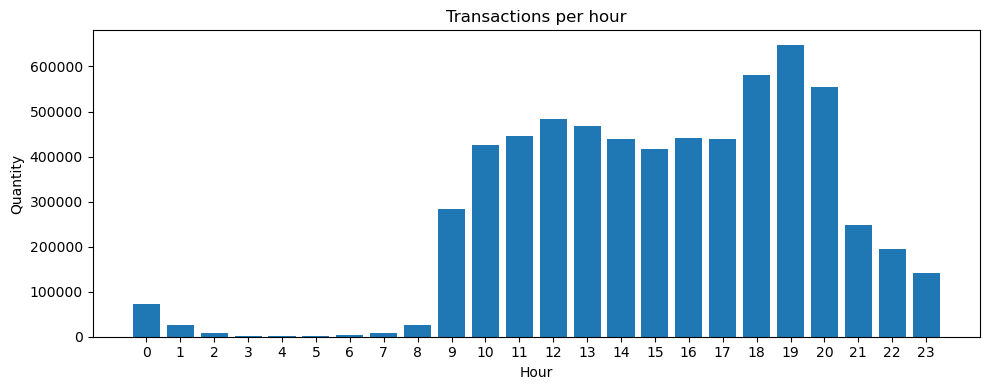

In [35]:
trans_hour = df["step_hour"].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.bar(trans_hour.index, trans_hour.values)
plt.title("Transactions per hour")
plt.xlabel("Hour")
plt.ylabel("Quantity")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

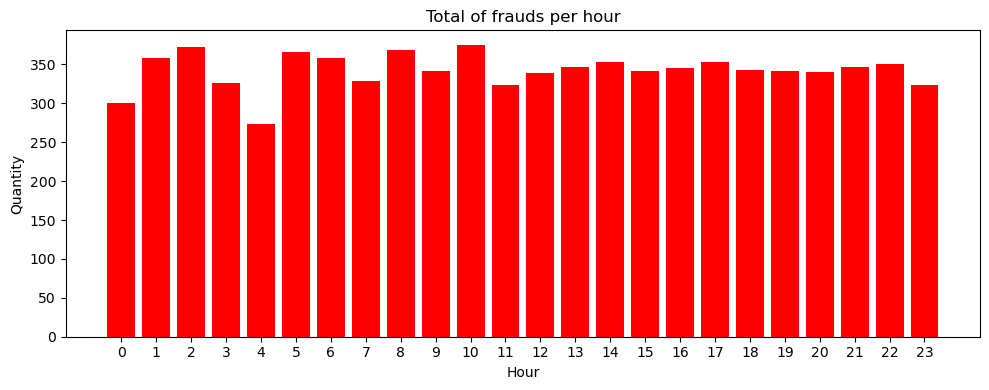

0     300
1     358
2     372
3     326
4     274
5     366
6     358
7     328
8     368
9     341
10    375
11    324
12    339
13    346
14    353
15    341
16    345
17    353
18    343
19    342
20    340
21    347
22    351
23    323
Name: step_hour, dtype: int64

In [42]:
frauds_hour = df[df["isFraud"] == 1]["step_hour"].value_counts().sort_index()

plt.figure(figsize=(10,4))
plt.bar(frauds_hour.index, frauds_hour.values, color="red")
plt.title("Total of frauds per hour")
plt.xlabel("Hour")
plt.ylabel("Quantity")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

frauds_hour

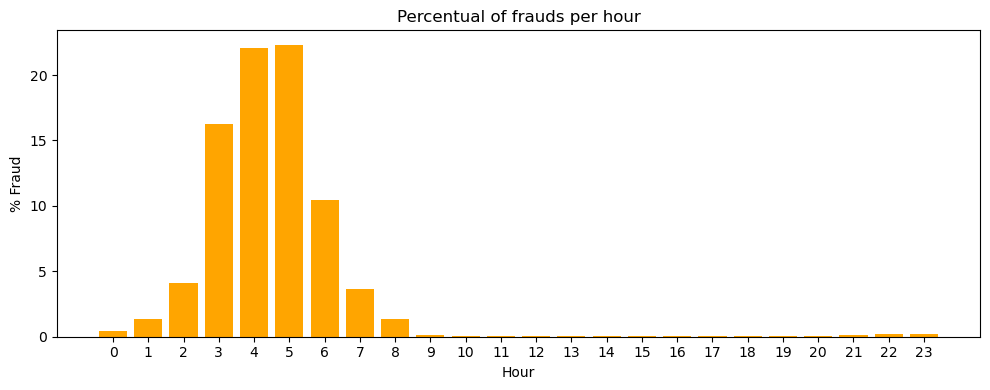

0      0.419071
1      1.320497
2      4.125083
3     16.243149
4     22.078969
5     22.303473
6     10.467836
7      3.649310
8      1.367267
9      0.120275
10     0.088084
11     0.072647
12     0.070126
13     0.073857
14     0.080291
15     0.081836
16     0.078123
17     0.080238
18     0.059086
19     0.052793
20     0.061402
21     0.140029
22     0.180412
23     0.228661
Name: step_hour, dtype: float64


In [43]:
percent_fraud_hour = (frauds_hour / trans_hour * 100).fillna(0)

plt.figure(figsize=(10,4))
plt.bar(percent_fraud_hour.index, percent_fraud_hour.values, color="orange")
plt.title("Percentual of frauds per hour")
plt.xlabel("Hour")
plt.ylabel("% Fraud")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

print(percentual_fraude_hora)

In [44]:
df["no_money_after_transaction"] = (
    (df["oldbalanceOrg"] > 0) &
    (np.isclose(df["amount"], df["oldbalanceOrg"]))  # amount == oldbalanceOrg
).astype(int)

In [46]:
total_no_money = df["no_money_after_transaction"].sum()

fraud_no_money = df[
    (df["isFraud"] == 1) & (df["no_money_after_transaction"] == 1)
].shape[0]

no_fraud_no_money = df[
    (df["isFraud"] == 0) & (df["no_money_after_transaction"] == 1)
].shape[0]


print(f"Clients with no money after transaction: {total_no_money:,}")
print(f"Clients with no money after fraud transaction: {fraud_no_money:,}")
print(f"Clients with no money after non fraud transaction: {no_fraud_no_money:,}")

Clients with no money after transaction: 8,025
Clients with no money after fraud transaction: 8,018
Clients with no money after non fraud transaction: 7


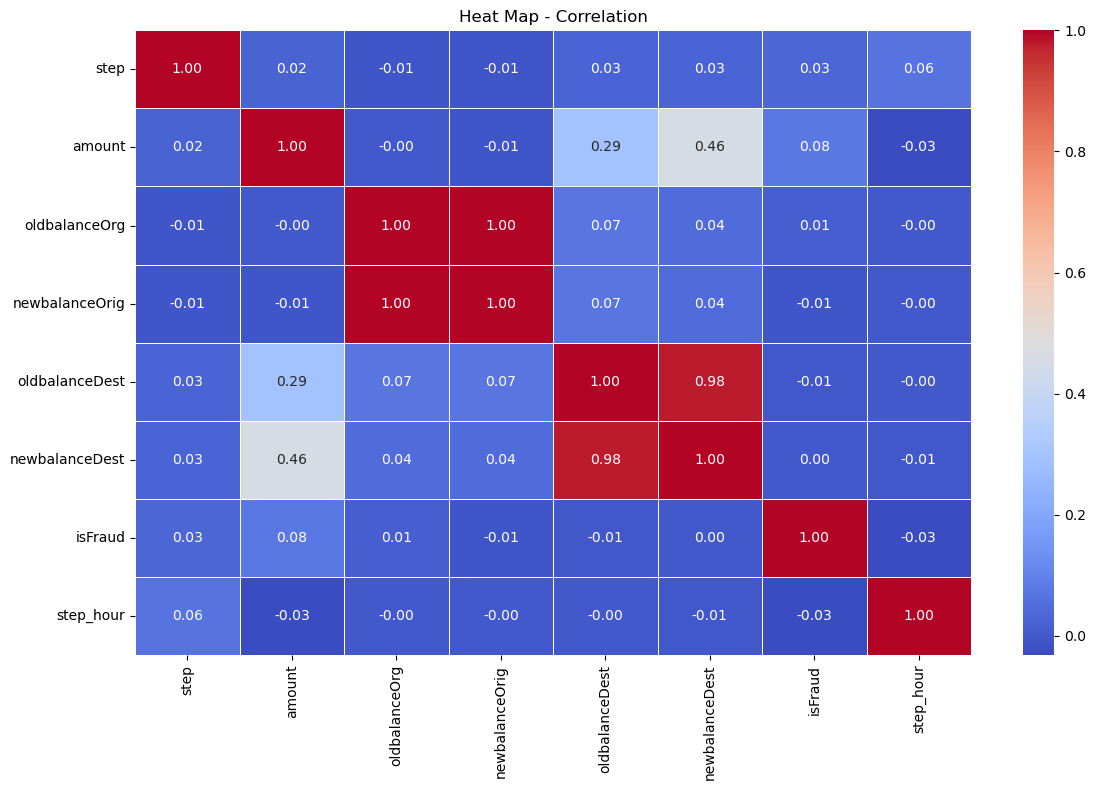

In [48]:
df_num = df.select_dtypes(include=["int64", "float64"])

corr = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Heat Map - Correlation")
plt.tight_layout()
plt.show()

In [50]:
df = df.drop(['newbalanceOrig','newbalanceDest','step'], axis = 1)
df.head()

,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,step_hour,no_money_after_transaction
0,PAYMENT,9839.64,170136.0,0.0,0,1,0
1,PAYMENT,1864.28,21249.0,0.0,0,1,0
2,TRANSFER,181.00,181.0,0.0,1,1,1
3,CASH_OUT,181.00,181.0,21182.0,1,1,1
4,PAYMENT,11668.14,41554.0,0.0,0,1,0


# Training Models

## Logistic Regression

In [69]:
df_lr = df.copy()
df_lr = pd.get_dummies(df_lr, columns=['type'], drop_first=False)
df_lr.head()

,amount,oldbalanceOrg,oldbalanceDest,isFraud,step_hour,no_money_after_transaction,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.0,0.0,0,1,0,0,0,0,1,0
1,1864.28,21249.0,0.0,0,1,0,0,0,0,1,0
2,181.00,181.0,0.0,1,1,1,0,0,0,0,1
3,181.00,181.0,21182.0,1,1,1,0,1,0,0,0
4,11668.14,41554.0,0.0,0,1,0,0,0,0,1,0


In [70]:
X_lr = df_lr.drop(columns=["isFraud"])
y_lr = df_lr["isFraud"]

In [71]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.30, random_state=42, stratify=y)

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lr)
X_test_scaled = scaler.transform(X_test_lr)

Average Precision: 99.44%
Precision Score: 99.88%
Recall Score: 98.38%
F1 Score: 99.12%
ROC AUC Score (test): 99.88%


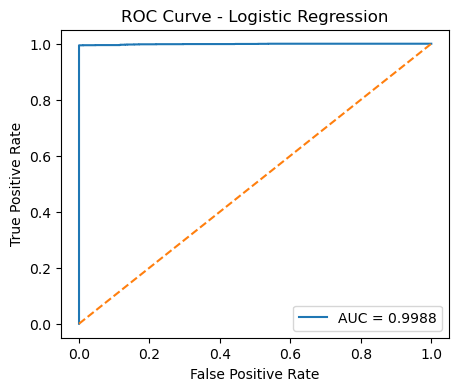

In [105]:
lr = LogisticRegression(max_iter=2000)
model(lr, X_train_scaled, y_train_lr, X_test_scaled, y_test_lr, title = 'Logistic Regression')

## XGBoost

In [115]:
df_xgb_le = df.copy()
df_xgb_ohe = df.copy()

In [116]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

## Training with Label Encoder

In [117]:
le = LabelEncoder()
df_xgb_le['type'] = le.fit_transform(df_xgb_le['type'])

In [118]:
X_le = df_xgb_le.drop(columns=["isFraud"])
y_le = df_xgb_le["isFraud"]

In [112]:
X_train_le, X_test_le, y_train_le, y_test_le = train_test_split(X_le, y_le, test_size=0.30, random_state=42, stratify=y)

Average Precision: 99.67%
Precision Score: 99.92%
Recall Score: 99.47%
F1 Score: 99.69%
ROC AUC Score (test): 99.94%


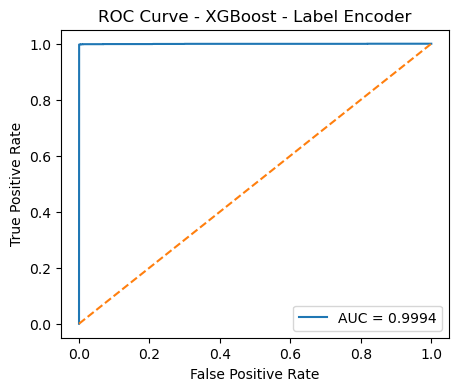

In [119]:
model(xgb, X_train_le, y_train_le, X_test_le, y_test_le, title = 'XGBoost - Label Encoder')

## Training with Dummy Types

In [121]:
df_xgb_ohe = pd.get_dummies(df_xgb_ohe, columns=['type'], drop_first=False)
df_xgb_ohe

,amount,oldbalanceOrg,oldbalanceDest,isFraud,step_hour,no_money_after_transaction,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9839.64,170136.00,0.00,0,1,0,0,0,0,1,0
1,1864.28,21249.00,0.00,0,1,0,0,0,0,1,0
2,181.00,181.00,0.00,1,1,1,0,0,0,0,1
3,181.00,181.00,21182.00,1,1,1,0,1,0,0,0
4,11668.14,41554.00,0.00,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,339682.13,0.00,1,23,1,0,1,0,0,0
6362616,6311409.28,6311409.28,0.00,1,23,1,0,0,0,0,1
6362617,6311409.28,6311409.28,68488.84,1,23,1,0,1,0,0,0
6362618,850002.52,850002.52,0.00,1,23,1,0,0,0,0,1


In [123]:
X_ohe = df_xgb_ohe.drop(columns=["isFraud"])
y_ohe = df_xgb_ohe["isFraud"]

In [124]:
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y_ohe, test_size=0.30, random_state=42, stratify=y)

Average Precision: 99.68%
Precision Score: 99.88%
Recall Score: 99.47%
F1 Score: 99.67%
ROC AUC Score (test): 99.94%


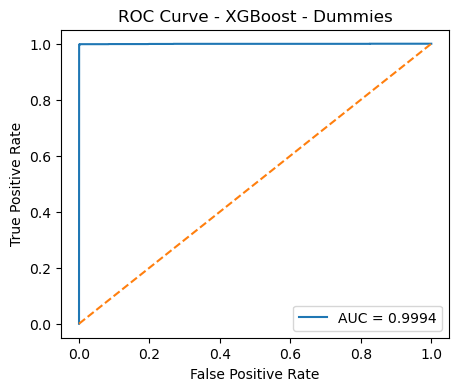

In [125]:
model(xgb, X_train_ohe, y_train_ohe, X_test_ohe, y_test_ohe, title = 'XGBoost - Dummies')